# Embeddings y Similitud Semántica
## Comparación TF-IDF vs. Embeddings de IA Generativa

### Requisitos antes de ejecutar este notebook:

* Contar con API key de OpenAI

Este notebook explora dos formas de representar texto como vectores numéricos y compara su capacidad para capturar **similitud semántica**:

| Técnica | Enfoque | Captura semántica |
|---------|---------|-------------------|
| **TF-IDF** | Frecuencia estadística de palabras | Solo similitud léxica |
| **OpenAI Embeddings** | Modelo de lenguaje preentrenado | Significado contextual |

El caso de uso central es la **polisemia**: palabras con el mismo léxico pero distintos significados (ej. *banco* financiero vs. *banco* de parque).

## Configuración del entorno

Se instala `langchain-openai` como interfaz para acceder a los modelos de embeddings de OpenAI a través de LangChain. También se importan las dependencias para cálculos numéricos (`numpy`), visualización (`matplotlib`, `seaborn`) y vectorización clásica de texto (`scikit-learn`).

In [1]:
#!uv add langchain-openai

## Generación de Embeddings con OpenAI

Los **embeddings** son representaciones vectoriales de texto en un espacio de alta dimensión. Textos con significado similar quedan "cercanos" en ese espacio, lo que permite medir su similitud semántica mediante distancias vectoriales.

Se utiliza el modelo `text-embedding-3-small` de OpenAI, que genera vectores de **1536 dimensiones** por cada fragmento de texto.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from getpass import getpass

In [3]:
openai_key = os.getenv("OPENAI_API_KEY")

if openai_key:
    print("OPENAI_API_KEY encontrada. ¡Todo listo para usar la API de OpenAI!")
else:
    raise ValueError("OPENAI_API_KEY no encontrada. Verifica tu archivo .env")

OPENAI_API_KEY encontrada. ¡Todo listo para usar la API de OpenAI!


Cada oración —independientemente de su longitud— se representa como un vector de **1536 números flotantes**. Esta representación densa captura el significado semántico del texto completo, no solo sus palabras individuales.

In [4]:
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(
    model="text-embedding-3-small", #text-embedding-3-small", #"text-embedding-3-large",
    openai_api_key=openai_key
)

docs = [
        "La gata maulla mucho y por eso se fue a la veterinaria",
        "La gata se enfermó y la llevaron a la veterinaria",
        "La gata me sirvió para cambiar la llanta",
        "Go"
    ]

embeddings = embeddings_model.embed_documents(docs)

print(f"Cantidad de embeddings: {len(embeddings)}")
print(f"Tamaño de cada oracion: {len(docs[0])}")
print(f"Tamaño de cada embedding: {len(embeddings[0])}")

Cantidad de embeddings: 4
Tamaño de cada oracion: 54
Tamaño de cada embedding: 1536


### Ejemplo práctico de similitud coseno

Se comparan tres oraciones: dos sobre mundiales de fútbol y una sobre LangChain. Se espera que las dos oraciones temáticamente relacionadas (ambas sobre fútbol) tengan una similitud coseno significativamente mayor entre sí que con la oración sobre tecnología.

In [5]:
len(docs), len(embeddings)

(4, 4)

In [6]:
for i in range(len(docs)):
    print(f"Oración: {docs[i]}")
    print(f"Embedding: {embeddings[i][:10]}...")  # Mostrar solo los primeros 10 valores del embedding
    print(f"Tamaño del embedding: {len(embeddings[i])}")
    print("-" * 50)

Oración: La gata maulla mucho y por eso se fue a la veterinaria
Embedding: [0.035400390625, -0.01910400390625, 0.00818634033203125, 0.039947509765625, -0.0169677734375, 0.0543212890625, -0.004047393798828125, 0.0303802490234375, -0.0145416259765625, 0.0042877197265625]...
Tamaño del embedding: 1536
--------------------------------------------------
Oración: La gata se enfermó y la llevaron a la veterinaria
Embedding: [0.0118865966796875, -0.01450347900390625, -0.0247802734375, 0.01438140869140625, -0.004558563232421875, 0.033477783203125, -0.031524658203125, 0.0550537109375, -0.0240936279296875, -0.007274627685546875]...
Tamaño del embedding: 1536
--------------------------------------------------
Oración: La gata me sirvió para cambiar la llanta
Embedding: [0.02215576171875, -0.06658935546875, -0.04156494140625, -0.005931854248046875, -0.0218963623046875, -0.0313720703125, -0.0247955322265625, 0.040069580078125, 0.002887725830078125, -0.0523681640625]...
Tamaño del embedding: 1536
---

# Funcion de similaridad

In [26]:
def cosine_similarity_simple(vec1, vec2):
    """
    Calcula la similitud coseno entre dos vectores
    """

    # Calcular el producto punto
    dot_product = np.dot(vec1, vec2)

    # Calcular las normas
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    # Calcular similitud coseno
    similarity = dot_product / (norm_vec1 * norm_vec2)

    return similarity

Los resultados confirman que los embeddings capturan relaciones semánticas correctamente:
- Textos sobre el **mismo tema** (mundiales de fútbol): similitud ~0.54
- Textos sobre **temas distintos** (fútbol vs. LangChain): similitud ~0.06

---

## Experimento: Polisemia en Español

A continuación se construye un dataset con **21 oraciones** que contienen palabras ambiguas del español (*banco*, *gato*, *capital*, *red*, *planta*), cada una usada en dos o más contextos semánticos distintos. El objetivo es evaluar si TF-IDF o los embeddings pueden distinguir esos significados.

In [8]:
textos = [
    "El mundial de futbol actul es en USA, Mexico y Canada",
    "Langchain es un framework para desarrollar agentes",
    "El anterior mundial de futbol fue en Qatar"
]

embeddings_textos = embeddings_model.embed_documents(textos)

In [27]:
len(embeddings_textos)

3

In [28]:
i = 0
j = 1
print(f"Los textos:\n'{textos[i]}' y '{textos[j]}'\ntienen una similitud coseno de: {cosine_similarity_simple(embeddings_textos[i], embeddings_textos[j])}")
print(f"dimensión de los embeddings: {len(embeddings_textos[i])} y {len(embeddings_textos[j])}")

Los textos:
'El mundial de futbol actul es en USA, Mexico y Canada' y 'Langchain es un framework para desarrollar agentes'
tienen una similitud coseno de: 0.060877494259788265
dimensión de los embeddings: 1536 y 1536


In [29]:
i = 0
j = 2
print(f"Los textos:\n'{textos[i]}' y '{textos[j]}'\ntienen una similitud coseno de: {cosine_similarity_simple(embeddings_textos[i], embeddings_textos[j])}")
print(f"dimensión de los embeddings: {len(embeddings_textos[i])} y {len(embeddings_textos[j])}")

Los textos:
'El mundial de futbol actul es en USA, Mexico y Canada' y 'El anterior mundial de futbol fue en Qatar'
tienen una similitud coseno de: 0.5447180528048586
dimensión de los embeddings: 1536 y 1536


In [30]:
i = 1
j = 2
print(f"Los textos:\n'{textos[i]}' y '{textos[j]}'\ntienen una similitud coseno de: {cosine_similarity_simple(embeddings_textos[i], embeddings_textos[j])}")
print(f"dimensión de los embeddings: {len(embeddings_textos[i])} y {len(embeddings_textos[j])}")

Los textos:
'Langchain es un framework para desarrollar agentes' y 'El anterior mundial de futbol fue en Qatar'
tienen una similitud coseno de: 0.0770797469747397
dimensión de los embeddings: 1536 y 1536


In [31]:
# Configuración visual
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [32]:
# Dataset de textos con similitudes léxicas pero diferentes significados
texts = [
    # Grupo 1: "banco" - institución financiera vs objeto para sentarse
    "Fui al banco a depositar mi dinero en la cuenta de ahorros",
    "Tengo mis ahorros en el banco, siempre voy a depositarlo",
    "Me senté en el banco del parque a descansar un momento",
    "El banco central subió las tasas de interés este mes",
    "Construí un banco de madera para el jardín",

    # Grupo 2: "gato" - animal vs herramienta
    "Mi gato negro duerme en el sofá toda la tarde",
    "Necesito un gato hidráulico para cambiar la llanta del carro",
    "El gato de mi vecina es muy cariñoso y juguetón",
    "El mecánico usó el gato para levantar el vehículo",

    # Grupo 3: "capital" - ciudad vs dinero
    "París es la capital de Francia y una ciudad hermosa",
    "Necesito más capital para invertir en mi negocio",
    "La capital del país tiene muchos monumentos históricos",
    "El capital inicial fue suficiente para empezar la empresa",

    # Grupo 4: "red" - internet vs color/malla
    "La red de internet está muy lenta hoy en casa",
    "Compré una red de pescar para ir al lago",
    "Mi computadora no se conecta a la red wifi",
    "Los pescadores lanzaron la red al mar temprano",

    # Grupo 5: "planta" - vegetal vs fábrica/piso
    "Esta planta verde necesita más agua y luz solar",
    "La planta industrial produce miles de productos diarios",
    "Mi oficina está en la planta baja del edificio",
    "Regalé una planta de flores a mi madre"
]

print(f"Total de textos: {len(texts)}")
print("\nPrimeros 5 textos:")
for i, text in enumerate(texts[:5]):
    print(f"{i+1}: {text}")

Total de textos: 21

Primeros 5 textos:
1: Fui al banco a depositar mi dinero en la cuenta de ahorros
2: Tengo mis ahorros en el banco, siempre voy a depositarlo
3: Me senté en el banco del parque a descansar un momento
4: El banco central subió las tasas de interés este mes
5: Construí un banco de madera para el jardín


# Vectorización de texto mediante "TF-IDF" (Frecuencia de término - Frecuencia inversa de documento)

Es una técnica matemática y un algoritmo de Machine Learning que convierte texto en números (vectores). Pondera cada palabra según su importancia: castiga los términos muy comunes y premia aquellos que son únicos y relevantes para un documento específico.

## Análisis de Casos de Polisemia

Se comparan pares de oraciones que comparten la misma palabra clave pero con diferente significado semántico. Para cada par se reporta:
- **Similitud TF-IDF**: basada en frecuencia de palabras compartidas
- **Similitud Embeddings**: basada en comprensión semántica del modelo

Un buen modelo semántico debería asignar **baja similitud** a textos con la misma palabra pero distinto significado, y **alta similitud** a textos sobre el mismo tema aunque usen palabras distintas.

In [33]:
print("IMPLEMENTANDO TF-IDF")
print("="*50)

# Crear y entrenar el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,
    min_df=1,
    max_df=0.8,
    stop_words='english',
    ngram_range=(1, 2)  # incluir bigramas
)

# Obtener la matriz TF-IDF
tfidf_matrix = tfidf_vectorizer.fit_transform(texts)
print(f"Forma de la matriz TF-IDF: {tfidf_matrix.shape}")

# Ver algunas características más importantes
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"Número total de características: {len(feature_names)}")
print(f"Primeras 10 características: {feature_names[:10]}")

IMPLEMENTANDO TF-IDF
Forma de la matriz TF-IDF: (21, 250)
Número total de características: 250
Primeras 10 características: ['agua' 'agua luz' 'ahorros' 'ahorros en' 'al' 'al banco' 'al lago'
 'al mar' 'baja' 'baja del']


# IA Generativa

In [34]:
# Obtener embeddings
print("Obteniendo embeddings...")
embeddings = embeddings_model.embed_documents(texts)
embeddings_array = np.array(embeddings)

print(f"Forma de la matriz de embeddings: {embeddings_array.shape}")
print(f"Dimensiones de cada embedding: {embeddings_array.shape[1]}")

Obteniendo embeddings...
Forma de la matriz de embeddings: (21, 1536)
Dimensiones de cada embedding: 1536


## Matrices de similitud

## Visualización de Matrices de Similitud

Los mapas de calor muestran la similitud coseno entre todos los pares de textos del dataset. Colores más brillantes (amarillo) indican mayor similitud; colores oscuros (azul/morado) indican menor similitud.

Se puede observar visualmente cómo los embeddings producen **agrupaciones temáticas coherentes** que TF-IDF no logra capturar.

In [35]:
print("CALCULANDO SIMILITUDES")

# Matriz de similitud TF-IDF
tfidf_similarities = cosine_similarity(tfidf_matrix)
print(f"Matriz de similitud TF-IDF calculada, shape: {tfidf_similarities.shape}")

# Matriz de similitud para embeddings
embeddings_similarities = cosine_similarity(embeddings_array)
print(f"Matriz de similitud Embeddings calculada, shape: {embeddings_similarities.shape}")

CALCULANDO SIMILITUDES
Matriz de similitud TF-IDF calculada, shape: (21, 21)
Matriz de similitud Embeddings calculada, shape: (21, 21)


## Conclusiones

| Aspecto | TF-IDF | Embeddings IA |
|---------|--------|---------------|
| Similitud media | ~0.03 | ~0.25 |
| Rango de valores | 0.00 – 0.18 | 0.05 – 0.72 |
| Captura polisemia | No diferencia significados | Distingue contextos semánticos |
| Sensibilidad al contexto | Solo palabras literales | Comprende significado |

**Conclusión principal**: Los embeddings de IA generativa capturan el significado semántico de forma mucho más rica que TF-IDF. Mientras TF-IDF trata *banco* como la misma entidad en todos los contextos, los embeddings reconocen que "banco financiero" y "banco de parque" son conceptos distintos.

Esta capacidad es fundamental para aplicaciones como:
- **Búsqueda semántica** (RAG — Retrieval-Augmented Generation)
- **Clasificación de texto**
- **Detección de duplicados semánticos**
- **Sistemas de recomendación**

In [36]:
def analizar_similitudes(texto_idx1, texto_idx2, nombre_par):
    print(f"\n{nombre_par}:")
    print(f"Texto 1: {texts[texto_idx1]}")
    print(f"Texto 2: {texts[texto_idx2]}")

    # TF-IDF
    tfidf_sim = tfidf_similarities[texto_idx1, texto_idx2]

    # Embeddings
    embedding_sim = embeddings_similarities[texto_idx1, texto_idx2]

    print(f"Similitud TF-IDF: {tfidf_sim:.4f}")
    print(f"Similitud Embeddings: {embedding_sim:.4f}")
    print(f"Diferencia: {abs(tfidf_sim - embedding_sim):.4f}")

In [37]:
# Mismo significado, palabras diferentes
analizar_similitudes(0, 1, "BANCO financiero (similares en significado)")


BANCO financiero (similares en significado):
Texto 1: Fui al banco a depositar mi dinero en la cuenta de ahorros
Texto 2: Tengo mis ahorros en el banco, siempre voy a depositarlo
Similitud TF-IDF: 0.1067
Similitud Embeddings: 0.7160
Diferencia: 0.6093


In [38]:
# Mismas palabras, diferente significado
analizar_similitudes(0, 2, "BANCO - financiero vs asiento (misma palabra, diferente significado)")


BANCO - financiero vs asiento (misma palabra, diferente significado):
Texto 1: Fui al banco a depositar mi dinero en la cuenta de ahorros
Texto 2: Me senté en el banco del parque a descansar un momento
Similitud TF-IDF: 0.0593
Similitud Embeddings: 0.4907
Diferencia: 0.4314


In [39]:
# Gato animal vs herramienta
analizar_similitudes(4, 5, "GATO - animal vs herramienta (misma palabra, diferente significado)")


GATO - animal vs herramienta (misma palabra, diferente significado):
Texto 1: Construí un banco de madera para el jardín
Texto 2: Mi gato negro duerme en el sofá toda la tarde
Similitud TF-IDF: 0.0261
Similitud Embeddings: 0.2814
Diferencia: 0.2553


In [40]:
# Capital ciudad vs dinero
analizar_similitudes(8, 9, "CAPITAL - ciudad vs dinero (misma palabra, diferente significado)")


CAPITAL - ciudad vs dinero (misma palabra, diferente significado):
Texto 1: El mecánico usó el gato para levantar el vehículo
Texto 2: París es la capital de Francia y una ciudad hermosa
Similitud TF-IDF: 0.0000
Similitud Embeddings: 0.0457
Diferencia: 0.0457


In [41]:
# Textos completamente diferentes
analizar_similitudes(2, 4, "Textos completamente diferentes (banco vs gato)")


Textos completamente diferentes (banco vs gato):
Texto 1: Me senté en el banco del parque a descansar un momento
Texto 2: Construí un banco de madera para el jardín
Similitud TF-IDF: 0.0735
Similitud Embeddings: 0.5369
Diferencia: 0.4634


GENERANDO VISUALIZACIONES


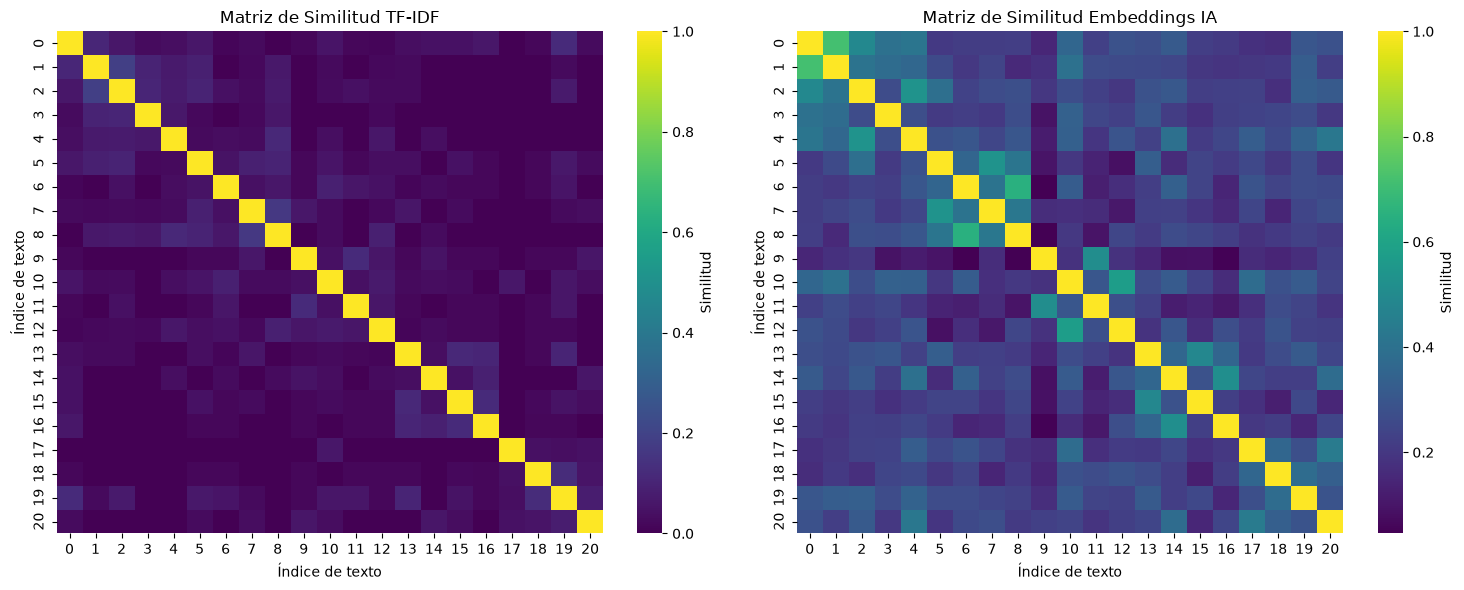

In [42]:
print("GENERANDO VISUALIZACIONES")

# Crear visualización de las matrices de similitud
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# TF-IDF heatmap
sns.heatmap(tfidf_similarities,
            annot=False,
            cmap='viridis',
            ax=axes[0],
            cbar_kws={'label': 'Similitud'})
axes[0].set_title('Matriz de Similitud TF-IDF')
axes[0].set_xlabel('Índice de texto')
axes[0].set_ylabel('Índice de texto')

# Embeddings heatmap
sns.heatmap(embeddings_similarities,
            annot=False,
            cmap='viridis',
            ax=axes[1],
            cbar_kws={'label': 'Similitud'})
axes[1].set_title('Matriz de Similitud Embeddings IA')
axes[1].set_xlabel('Índice de texto')
axes[1].set_ylabel('Índice de texto')

plt.tight_layout()
plt.show()

In [43]:
# Obtener solo el triángulo superior (sin diagonal) para evitar autocomparaciones
triu_indices = np.triu_indices_from(tfidf_similarities, k=1)
tfidf_upper = tfidf_similarities[triu_indices]
embeddings_upper = embeddings_similarities[triu_indices]

print(f"Estadísticas TF-IDF:")
print(f"  Media: {np.mean(tfidf_upper):.4f}")
print(f"  Mediana: {np.median(tfidf_upper):.4f}")
print(f"  Std: {np.std(tfidf_upper):.4f}")
print(f"  Min: {np.min(tfidf_upper):.4f}")
print(f"  Max: {np.max(tfidf_upper):.4f}")

print(f"\nEstadísticas Embeddings:")
print(f"  Media: {np.mean(embeddings_upper):.4f}")
print(f"  Mediana: {np.median(embeddings_upper):.4f}")
print(f"  Std: {np.std(embeddings_upper):.4f}")
print(f"  Min: {np.min(embeddings_upper):.4f}")
print(f"  Max: {np.max(embeddings_upper):.4f}")

Estadísticas TF-IDF:
  Media: 0.0302
  Mediana: 0.0201
  Std: 0.0339
  Min: 0.0000
  Max: 0.1837

Estadísticas Embeddings:
  Media: 0.2529
  Mediana: 0.2369
  Std: 0.1012
  Min: 0.0457
  Max: 0.7160
